# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


In [1]:
G=6.6743e-11 # m^3/kg/s^2
g=9.81 #m/s^2
m_e=5.972e24 #kg 
m_m=7.35e22 #kg 
r_e=6378.1e3 #m
r_m=1738.1e3 #m
omega=7.272e-5 #rad/s

from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

In [2]:

d=4000 #m
t_simple=np.sqrt((2*d)/g)
print(t_simple)

28.55686245854129


  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  3.030e-01 ...  2.970e+01  3.000e+01]
        y: [[ 0.000e+00 -4.504e-01 ... -4.326e+03 -4.414e+03]
            [ 0.000e+00 -2.973e+00 ... -2.913e+02 -2.943e+02]]
      sol: None
 t_events: [array([ 2.856e+01])]
 y_events: [array([[-4.000e+03, -2.801e+02]])]
     nfev: 44
     njev: 0
      nlu: 0


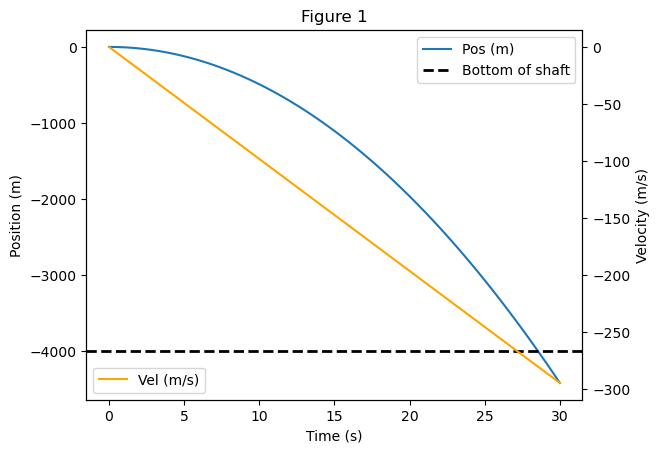

In [3]:

alpha=0
gamma=0
def derivatives(t,s):
    assert len(s)==2
    y,v=s
    dydt=v
    dvdt=-g+alpha*np.abs(dydt)**gamma
    return [dydt,dvdt]

def collision(t,s):
    return s[0]+4000


y0=[0.0,0.0]
t_span=(0,30)
t_eval=np.linspace(*t_span,100)
soln=solve_ivp(derivatives,t_span,y0,t_eval=t_eval,events=collision)

t=soln.t
y=soln.y[0] 
v=soln.y[1] 

fig,ax1=plt.subplots()
ax1.plot(t,y,label="Pos (m)")
ax1.axhline(y=-4000,label="Bottom of shaft",linewidth=2,ls="--",color="k")
ax1.set_title("Figure 1")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Position (m)")

ax2=ax1.twinx()
ax2.plot(t,v,color="orange",label="Vel (m/s)")
ax2.set_ylabel("Velocity (m/s)")

ax1.legend(loc="upper right")
ax2.legend(loc="lower left")
print(soln)


By using events with solve_ivp, I got a collision time of 28.56 seconds. This is the exact same number as my rounded analytic calculation (28.55686245854129).

## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  3.030e-01 ...  2.970e+01  3.000e+01]
        y: [[ 6.378e+06  6.378e+06 ...  6.374e+06  6.374e+06]
            [ 0.000e+00 -2.973e+00 ... -2.913e+02 -2.942e+02]]
      sol: None
 t_events: [array([ 2.856e+01])]
 y_events: [array([[ 6.374e+06, -2.801e+02]])]
     nfev: 44
     njev: 0
      nlu: 0
fall time: [28.55835511]


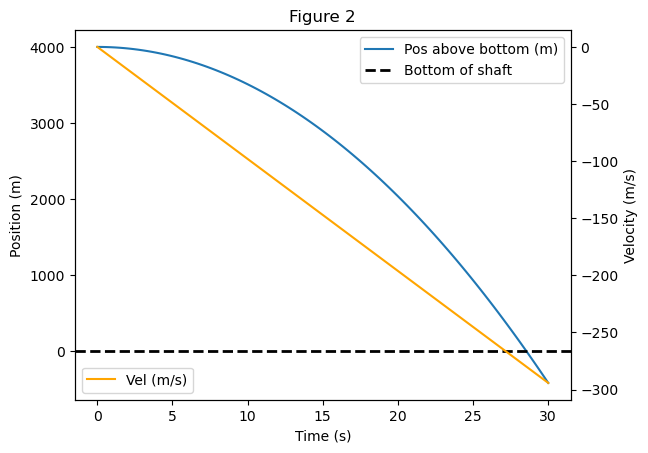

In [4]:
alpha=0
gamma=0
def derivatives(t,s):
    assert len(s)==2
    y,v=s
    dydt=v
    g_real=g*(y/r_e)
    dvdt=-g_real+alpha*np.abs(dydt)**gamma
    return [dydt,dvdt]

def collision(t,s):
    return s[0]-(r_e-4000)


y0=[r_e,0.0]
t_span=(0,30)
t_eval=np.linspace(*t_span,100)
soln=solve_ivp(derivatives,t_span,y0,t_eval=t_eval,events=collision)

t=soln.t
y=soln.y[0] 
v=soln.y[1] 

fig,ax1=plt.subplots()
ax1.plot(t,y-(r_e-4000),label="Pos above bottom (m)")
ax1.axhline(y=0,label="Bottom of shaft",linewidth=2,ls="--",color="k")
ax1.set_title("Figure 2")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Position (m)")

ax2=ax1.twinx()
ax2.plot(t,v,color="orange",label="Vel (m/s)")
ax2.set_ylabel("Velocity (m/s)")

ax1.legend(loc="upper right")
ax2.legend(loc="lower left")
print(soln)
print("fall time:", soln.t_events[0])

A height dependent g has a negligible fall time for reaching the bottom of the shaft. This is because the distance from the surface of the Earth to the bottom of the shaft is very small compared to the radius of the Earth so g decreases by a very small amount. The time to reach the bottom of the shaft is the same in both situations.

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.010e+00 ...  9.899e+01  1.000e+02]
        y: [[ 6.378e+06  6.378e+06 ...  6.373e+06  6.373e+06]
            [ 0.000e+00 -9.781e+00 ... -4.997e+01 -4.997e+01]]
      sol: None
 t_events: [array([ 8.354e+01])]
 y_events: [array([[ 6.374e+06, -4.997e+01]])]
     nfev: 140
     njev: 0
      nlu: 0
fall time: [83.54308278]


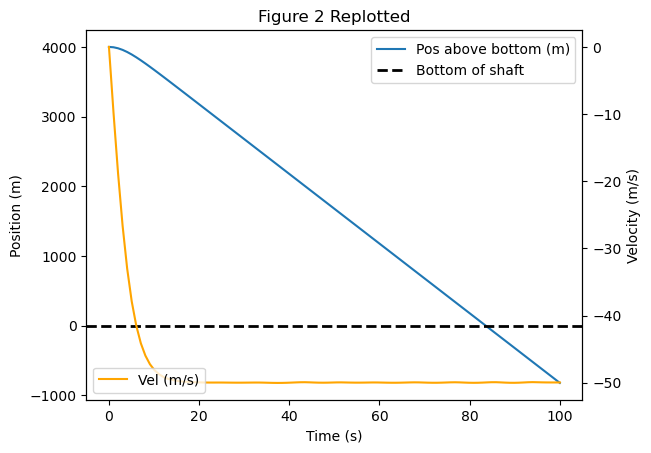

In [5]:
# turning on drag by setting alpha to 1 and setting gamma to 2
v_t=50 # terminal velocity
gamma=2
# calibrate alpha based on the terminal velocity of the mass. alpha = g / v_t^gamma
# this equation comes from the newton's second law and 
alpha=g/(v_t**gamma)
def derivatives(t,s):
    assert len(s)==2
    y,v=s
    dydt=v
    g_real=g*(y/r_e)
    dvdt=-g_real+alpha*np.abs(dydt)**gamma
    return [dydt,dvdt]

def collision(t,s):
    return s[0]-(r_e-4000)


y0=[r_e,0.0]
t_span=(0,100)
t_eval=np.linspace(*t_span,100)
soln=solve_ivp(derivatives,t_span,y0,t_eval=t_eval,events=collision)

t=soln.t
y=soln.y[0] 
v=soln.y[1] 

fig,ax1=plt.subplots()
ax1.plot(t,y-(r_e-4000),label="Pos above bottom (m)")
ax1.axhline(y=0,label="Bottom of shaft",linewidth=2,ls="--",color="k")
ax1.set_title("Figure 2 Replotted")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Position (m)")

ax2=ax1.twinx()
ax2.plot(t,v,color="orange",label="Vel (m/s)")
ax2.set_ylabel("Velocity (m/s)")

ax1.legend(loc="upper right")
ax2.legend(loc="lower left")
print(soln)
print("fall time:", soln.t_events[0])

Drag greatly affects the fall time of the mass since the mass cannot continuously accelerate to speeds beyond its terminal velocity.

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




DRAG OFF -------------
  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  5.051e-01 ...  2.778e+01  2.828e+01]
        y: [[ 6.378e+06  6.378e+06 ...  6.374e+06  6.374e+06]
            [ 0.000e+00 -4.955e+00 ... -2.724e+02 -2.774e+02]
            [ 0.000e+00 -3.063e-05 ... -5.096e+00 -5.379e+00]
            [ 0.000e+00 -1.820e-04 ... -5.504e-01 -5.706e-01]]
      sol: None
 t_events: [array([ 2.856e+01]), array([ 2.191e+01])]
 y_events: [array([[ 6.374e+06, -2.801e+02, -5.538e+00, -5.818e-01]]), array([[ 6.376e+06, -2.149e+02, -2.500e+00, -3.424e-01]])]
     nfev: 44
     njev: 0
      nlu: 0
fall time to bottom: [28.55837573]
fall time to side of shaft: [21.90724193]
DRAG ON -------------
  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  1.010e+00 ...  8.182e+01  8.283e+01]
        y: [[ 6.378e+06  6.378e+06 ...  6.374e+06  6.374e+06]
            [ 0.000e+00 -9.781e+00 ... -5.005e+01 -5.003e+01]
   

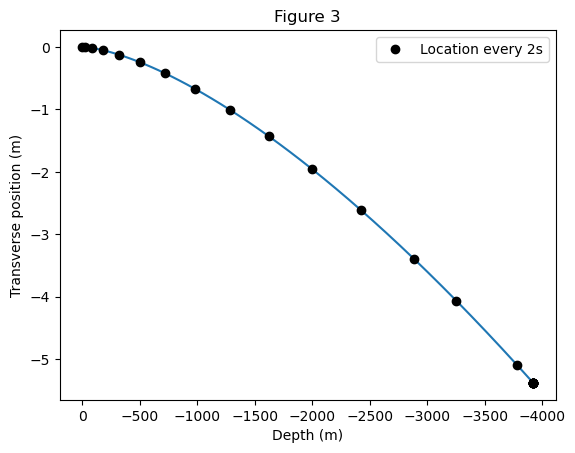

In [6]:
alpha=0
gamma=0
def derivatives(t,s):
    assert len(s)==4
    y,v_y,x,v_x=s
    dydt=v_y
    dxdt=v_x
    g_real=g*(y/r_e)
    dvdt_y=-g_real+alpha*np.abs(dydt)**gamma-(2*omega*dxdt) # add new y acceleration terms
    dvdt_x=2*omega*dydt # add new x acceleration terms (just coriolis term)
    return [dydt,dvdt_y,dxdt,dvdt_x]

def collision_bottom(t,s): # add new collision event for when x=side of shaft
    return s[0]-(r_e-4000)

def collision_side(t,s):
    return s[2]+2.5

collision_bottom.terminal = True
collision_bottom.direction = -1

y0=[r_e,0.0,0.0,0.0]
t_span=(0,50)
t_eval=np.linspace(*t_span,100)
soln=solve_ivp(derivatives,t_span,y0,t_eval=t_eval,events=[collision_bottom,collision_side])

t=soln.t
y=soln.y[0] 
v_y=soln.y[1] 
x=soln.y[2] 
v_x=soln.y[3]

dots=np.arange(0,50,2) # times
dots_i=[np.argmin(np.abs(t-td)) for td in dots] # indices

fig,ax1=plt.subplots()
ax1.plot(y-r_e,x)
ax1.plot(y[dots_i]-r_e,x[dots_i],"ko",label="Location every 2s")
ax1.set_xlabel("Depth (m)")
ax1.set_ylabel("Transverse position (m)")
ax1.legend(loc="upper right")
ax1.set_title("Figure 3")
ax1.invert_xaxis()

print("DRAG OFF -------------")
print(soln)
print("fall time to bottom:", soln.t_events[0])
print("fall time to side of shaft:", soln.t_events[1])

# TURNING ON DRAG
# problem doesn't specifically ask me to replot so I just reevaluated with solve_ivp to get the event times. My comment on the effect of drag is in a markdown cell below the plot
# redefine derivatives with alpha and gamma terms
v_t=50
gamma=2
alpha=g/(v_t**gamma)

def derivatives(t,s):
    assert len(s)==4
    y,v_y,x,v_x=s
    dydt=v_y
    dxdt=v_x
    g_real=g*(y/r_e)
    dvdt_y=-g_real+alpha*np.abs(dydt)**gamma-(2*omega*dxdt) # add new y acceleration terms
    dvdt_x=2*omega*dydt # add new x acceleration terms (just coriolis term)
    return [dydt,dvdt_y,dxdt,dvdt_x]

# change timespan and dots
t_span=(0,100)
t_eval=np.linspace(*t_span,100)

soln=solve_ivp(derivatives,t_span,y0,t_eval=t_eval,events=[collision_bottom,collision_side])
print("DRAG ON -------------")
print(soln)
print("fall time to bottom:", soln.t_events[0])
print("fall time to side of shaft:", soln.t_events[1])

The test mass bumps into the wall first after 21.9 seconds. Turning drag on does make a difference. Drag causes the test mass to hit the wall at a later time of 29.6 seconds. The drag slows the effect of the coriolis force on the mass.

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.001e+01 ...  9.990e+03  1.000e+04]
        y: [[ 6.378e+06  6.378e+06 ...  6.279e+06  6.292e+06]
            [ 0.000e+00 -9.820e+01 ...  1.392e+03  1.295e+03]]
      sol: None
 t_events: [array([ 2.522e+03,  2.545e+03,  7.588e+03,  7.611e+03]), array([ 1.267e+03,  6.333e+03])]
 y_events: [array([[-6.377e+06, -1.119e+02],
                  [-6.377e+06,  1.119e+02],
                  [-6.377e+06, -1.119e+02],
                  [-6.377e+06,  1.119e+02]]), array([[-7.276e-10, -7.910e+03],
                  [-1.150e-09, -7.910e+03]])]
     nfev: 1586
     njev: 0
      nlu: 0
time to reach other side: [2521.74746409 2544.55398053 7588.04895171 7610.85538218]
time to reach center: [1266.57536116 6332.87680579]
speed at center: [[-7.27595761e-10 -7.91006707e+03]
 [-1.14960130e-09 -7.91006706e+03]]


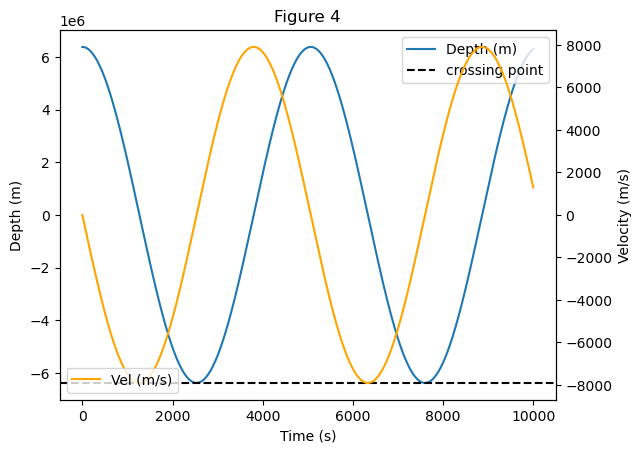

In [7]:
alpha=0
gamma=0
def derivatives(t,s):
    assert len(s)==2
    y,v=s
    dydt=v
    g_real=g*(y/r_e)
    dvdt=-g_real
    return [dydt,dvdt]

def other_side(t,s):
    return s[0]+r_e*.9999

def center(t,s):
    return s[0]
center.direction=-1

y0=[r_e,0.0] 
t_span=(0,10000)
t_eval=np.linspace(*t_span,1000)
soln=solve_ivp(derivatives,t_span,y0,t_eval=t_eval,events=[other_side,center],rtol=1E-9, atol=1E-9)

t=soln.t
y=soln.y[0] 
v=soln.y[1] 

fig,ax1=plt.subplots()
ax1.plot(t,y,label="Depth (m)")
ax1.set_title("Figure 4")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Depth (m)")
ax1.axhline(y=-r_e,label="crossing point",ls="--",color="k")

ax2=ax1.twinx()
ax2.plot(t,v,color="orange",label="Vel (m/s)")
ax2.set_ylabel("Velocity (m/s)")

ax1.legend(loc="upper right")
ax2.legend(loc="lower left")
print(soln)
print("time to reach other side:", soln.t_events[0])
print("time to reach center:", soln.t_events[1])
print("speed at center:",soln.y_events[1])

In figure 4 I see the velocity of the mass and the depth of the mass oscillating. The depth oscillates around 0 and so does the velocity. There's a phase shift between position and velocity of 90 degrees (velocity leads the displacement). This is simple harmonic motion.

It takes the object 2520.3 seconds to reach the other side. To reach the center, it takes 1266.6 seconds. The speed at the center is 7910.1 meters per second.

The orbital period is 5063.7 seconds. The center crossing time is .25 of the orbital period.


## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

Text(0, 0.5, 'Normalized density')

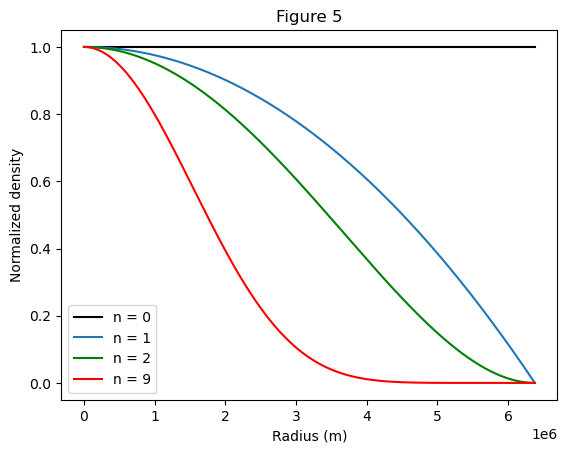

In [8]:
def p(r,n):
    return 1*(1-((r**2)/(r_e**2)))**n


r_range=np.linspace(0.01,r_e,1000)
fig,ax=plt.subplots()
ax.plot(r_range,p(r_range,0),label="n = 0",color="k")
ax.plot(r_range,p(r_range,1),label="n = 1")
ax.plot(r_range,p(r_range,2),label="n = 2",color="g")
ax.plot(r_range,p(r_range,9),label="n = 9",color="r")
ax.legend()
ax.set_title("Figure 5")
ax.set_xlabel("Radius (m)")
ax.set_ylabel("Normalized density")

### Part 5, Section B (Forces)

5494.867409551201


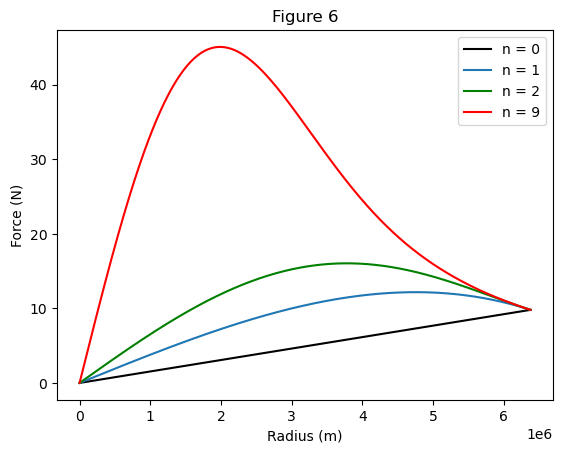

In [9]:
from scipy.integrate import quad

#calculating valid normalization factors & redefining equation for density with new normalization factor

rho_vals={}
for n in [0,1,2,9]:
    def integrand(r):
        return 4*np.pi*r**2*(1-(r**2/r_e**2))**n

    integral,err=quad(integrand,0,r_e)
    rho_vals[n]=m_e/integral

def p(r,n):
    return rho_vals[n]*(1-((r**2)/(r_e**2)))**n

def func(rp,n):
        return 4*np.pi*rp**2*p(rp,n)
    
def mass(r,n):
    m,err=quad(func,0,r,args=(n,))
    return m

def force(r,n):
    return G*mass(r,n)/(r**2)
    
force_vect=np.vectorize(force)

fig,ax=plt.subplots()
ax.plot(r_range,force_vect(r_range,0),label="n = 0",color="k")
ax.plot(r_range,force_vect(r_range,1),label="n = 1")
ax.plot(r_range,force_vect(r_range,2),label="n = 2",color="g")
ax.plot(r_range,force_vect(r_range,9),label="n = 9",color="r")
ax.set_title("Figure 6")
ax.set_ylabel("Force (N)")
ax.set_xlabel("Radius (m)")
ax.legend()
print(rho_vals[0])

### Part 5, Section C (Equations of Motion)

Time to reach other side:  [2523.27543216 7592.64667479]
Time to reach center:  [1267.3427999  6336.71399952]
Speed at center:  [[-8.73114914e-10 -7.90527713e+03]
 [-2.47382559e-10 -7.90527712e+03]]
Time to reach other side:  [2181.61610114 6567.66810768]
Time to reach center:  [1096.5129862  5482.56492764 9868.61686436]
Speed at center:  [[ 5.82076609e-10 -1.04576987e+04]
 [ 1.67347025e-09 -1.04576987e+04]
 [ 6.40284270e-10 -1.04576986e+04]]
Time to reach other side:  [2058.74142038 6199.04406509]
Time to reach center:  [1035.07564711 5175.37823196 9315.68081172]
Speed at center:  [[ 1.24418875e-09 -1.21828503e+04]
 [ 4.04543243e-09 -1.21828503e+04]
 [-7.02493708e-09 -1.21828502e+04]]
Time to reach other side:  [1876.14520353 5651.25541179 9426.36561142]
Time to reach center:  [ 943.77753128 4718.88765055 8493.99776138]
Speed at center:  [[ 6.22094376e-10 -1.83706738e+04]
 [-7.95444066e-09 -1.83706738e+04]
 [-1.47811079e-08 -1.83706738e+04]]


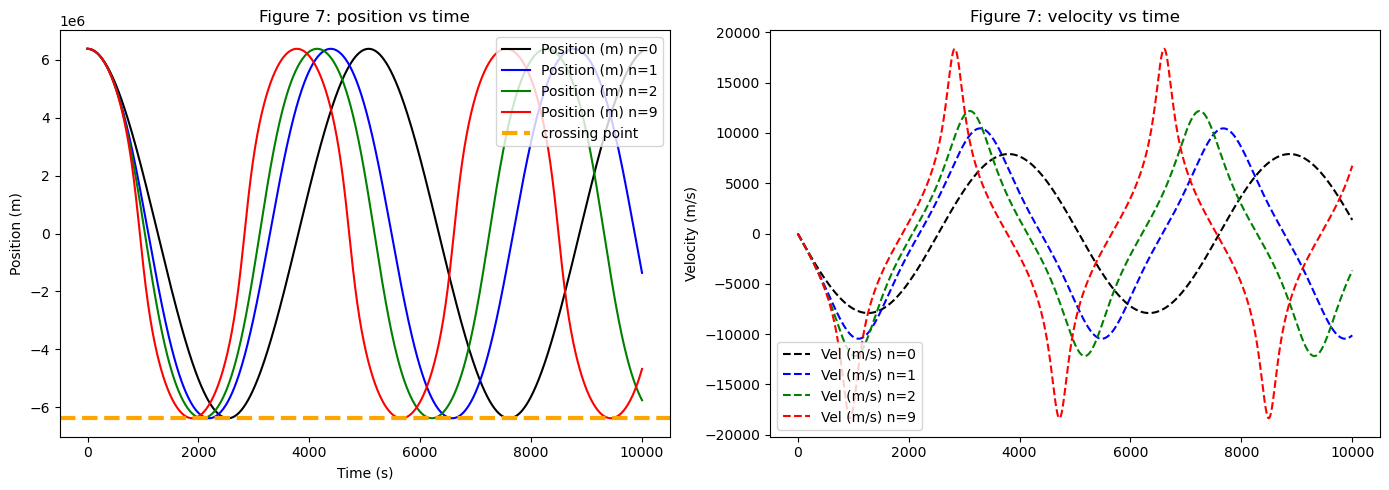

In [10]:
def derivatives(t,s,n):
    assert len(s)==2
    y,v=s
    dydt=v
    dvdt=-force_vect(y,n)
    return [dydt,dvdt]

def other_side(t,s,n):
    return s[0]+r_e*.9999

def center(t,s,n):
    return s[0]
center.direction=-1
other_side.direction=-1

y0=[r_e,0.0] 
t_span=(0,10000)
t_eval=np.linspace(*t_span,1000)
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5)) # Graphing them in one figure like figure1/2 looked too messy and it was incomprehensible.

colors = {0:"k",1:"b",2:"g",9:"r"}
solutions_earth={}
for n in [0,1,2,9]:
    soln=solve_ivp(derivatives,t_span,y0,args=(n,),t_eval=t_eval,events=[other_side,center],rtol=1E-9, atol=1E-9)
    solutions_earth[n]=soln
    t=soln.t
    y=soln.y[0]
    v=soln.y[1]
    ax1.plot(t,y,color=colors[n],label=f"Position (m) n={n}")
    ax2.plot(t,v,color=colors[n],ls="--",label=f"Vel (m/s) n={n}")

ax1.set_title("Figure 7: position vs time")
ax2.set_title("Figure 7: velocity vs time")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Position (m)")
ax1.axhline(y=-r_e,label="crossing point",ls="--",color="orange",lw=3)
ax2.set_ylabel("Velocity (m/s)")
ax1.legend(loc="upper right")
ax2.legend(loc="lower left")
plt.tight_layout()

for n in [0,1,2,9]:
    print(f"Time to reach other side: ",solutions_earth[n].t_events[0])
    print(f"Time to reach center: ",solutions_earth[n].t_events[1])
    print(f"Speed at center: ",solutions_earth[n].y_events[1])

For n=0,1,2,9, the times to reach the center are 1267.3, 1096.5, 1035.1, and 943.78 seconds respectively. The speeds achieved at those times are 7.905e3, 1.046e4, 1.218e4, and 1.837e4 m/s respectively.

## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


In [11]:
rho_vals={}
for n in [0,1,2,3,4,5,6,7,8,9]:
    def integrand(r):
        return 4*np.pi*r**2*(1-(r**2/r_m**2))**n

    integral,err=quad(integrand,0,r_m)
    rho_vals[n]=m_m/integral

def p(r,n):
    return rho_vals[n]*(1-((r**2)/(r_m**2)))**n

def func(rp,n):
        return 4*np.pi*rp**2*p(rp,n)
    
def mass(r,n):
    m,err=quad(func,0,r,args=(n,))
    return m

def force(r,n):
    return G*mass(r,n)/(r**2)
    
force_vect=np.vectorize(force)

def derivatives(t,s,n):
    assert len(s)==2
    y,v=s
    dydt=v
    dvdt=-force_vect(y,n)
    return [dydt,dvdt]

def other_side(t,s,n):
    return s[0]+r_m*.9999

def center(t,s,n):
    return s[0]
center.direction=-1
other_side.direction=-1

y0=[r_m,0.0] 
t_span=(0,10000)
t_eval=np.linspace(*t_span,1000)

solutions={}
for n in [0,1,2,3,4,5,6,7,8,9]:
    soln=solve_ivp(derivatives,t_span,y0,args=(n,),t_eval=t_eval,events=[other_side,center],rtol=1E-9, atol=1E-9)
    solutions[n]=soln

# n=0 CONSTANT DENSITY
for n in [0,1,2,9]:
    print(f"n = {n} ---------------")
    print(f"Time to reach other side: ",solutions[n].t_events[0])
    print(f"Time to reach center: ",solutions[n].t_events[1])
    print(f"Speed at center: ",solutions[n].y_events[1])

print(rho_vals[0])

n = 0 ---------------
Time to reach other side:  [3235.60905683 9736.08985892]
Time to reach center:  [1625.12018672 8125.60093361]
Speed at center:  [[-2.91038305e-11 -1.67999950e+03]
 [-3.89263732e-10 -1.67999949e+03]]
n = 1 ---------------
Time to reach other side:  [2797.49754048 8421.7545737 ]
Time to reach center:  [1406.06423852 7030.32118824]
Speed at center:  [[ 7.08268999e-11 -2.22243043e+03]
 [ 9.54969437e-11 -2.22243043e+03]]
n = 2 ---------------
Time to reach other side:  [2639.93470578 7949.06606912]
Time to reach center:  [1327.28282279 6636.41410936]
Speed at center:  [[ 4.54747351e-11 -2.58905311e+03]
 [-8.46284820e-10 -2.58905310e+03]]
n = 9 ---------------
Time to reach other side:  [2405.79063839 7246.63386337]
Time to reach center:  [1210.21077957 6051.05389035]
Speed at center:  [[ 4.12001100e-10 -3.90406588e+03]
 [ 1.38697942e-09 -3.90406587e+03]]
3341.7538038703183


If we assume the density of the moon to be constant, we get a travel time to the center of 1625 seconds.

If a constant Moon density is assumed, the density of the Moon is 3341 kg/m^3. This is 60.8% of the density of the Earth (5495 kg/m^3 if constant Earth density assumed).

Text(0.5, 1.0, 'Fall time vs Density')

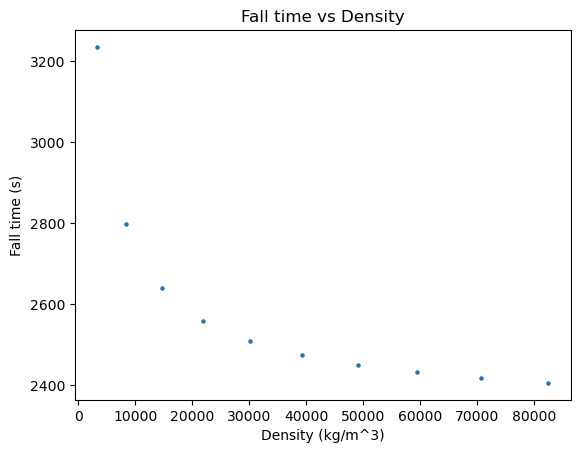

In [12]:
fig,ax=plt.subplots()
densities=[]
fall_times=[]
for n in solutions:
    densities.append(rho_vals[n])
    fall_times.append(solutions[n].t_events[0][0])
    
ax.scatter(densities,fall_times,s=5)
ax.set_xlabel("Density (kg/m^3)")
ax.set_ylabel("Fall time (s)")
ax.set_title("Fall time vs Density")

We can figure out the relationship between fall time and density creating a plot of densities and their periods. After creating this plot of increasing densities, it is clear that fall time and density have an inverse square root relationship ($t \propto \frac{1}{\sqrt{density}}$)

## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

In [13]:
sol_n0=solutions_earth[0]
t_n0=sol_n0.t

sol_n9=solutions_earth[9]
t_n9=sol_n9.t

dt=t_n0[1]-t_n0[0]


n0_fft=np.fft.rfft(sol_n0.y[0])
freq_n0=np.fft.rfftfreq(len(t_n0),dt)

n9_fft=np.fft.rfft(sol_n9.y[0])
freq_n9=np.fft.rfftfreq(len(t_n9),dt)

Text(0, 0.5, '|FFT|')

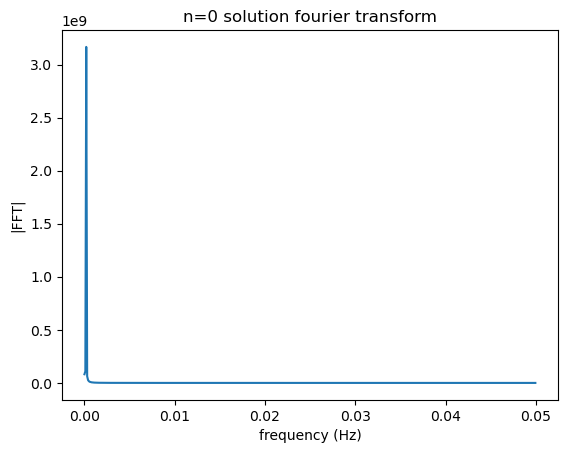

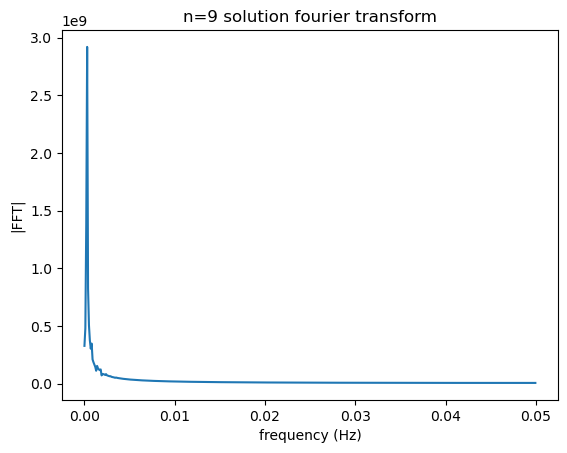

In [14]:
fig,ax=plt.subplots()
ax.plot(freq_n0,np.abs(n0_fft))
ax.set_title("n=0 solution fourier transform")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("|FFT|")

fig,ax=plt.subplots()
ax.plot(freq_n9,np.abs(n9_fft))
ax.set_title("n=9 solution fourier transform")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("|FFT|")

**Describe what we see here:**
For both of my fourier transforms I see a peak just beyond the frequency of 0 Hz. The peak is stronger for n=0 where Earth's density is constant and weaker for n=9 where Earth's density is more focused in the center.